In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from aux_func import get_data
from mosqlient.scoring import compute_wis

In [2]:
code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

state_to_code = {value: key for key, value in code_to_state.items()}

geo_dengue = [2931350,2933307,2302503,3119401,
              3549805,3541406,1200401,1200203,
              1716109,4113700,4103701,4104808,
              5201405,5102637,5215231]

geo_chik = [2211001,2931350,3143302,3119401,
            1721000,1716109,4104808,4219507,
            5103403,5102637] 

In [4]:
df_dengue_state, df_dengue_city  = get_data(disease = 'dengue')
df_chik_state, df_chik_city  = get_data(disease = 'chikungunya')

In [5]:
df_dengue_state

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115
...,...,...,...
23188,2026-06-14,43,61
23189,2026-06-14,50,129
23190,2026-06-14,51,148
23191,2026-06-14,52,638


In [6]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [7]:
df_preds[["date", "adm_1", "validation"]].drop_duplicates(
                subset=["date", "adm_1", "validation"],
                keep="first"
            )

,date,adm_1,validation
0,2022-10-09,12,1
1,2022-10-16,12,1
2,2022-10-23,12,1
3,2022-10-30,12,1
4,2022-11-06,12,1
...,...,...,...
16029,2026-09-06,32,4
16030,2026-09-13,32,4
16031,2026-09-20,32,4
16032,2026-09-27,32,4


In [8]:
df_dengue_state["date"] = pd.to_datetime(df_dengue_state["date"])

df_total_cases = (
    df_dengue_state.merge(
        df_preds[["date", "adm_1", "validation"]].drop_duplicates(
                subset=["date", "adm_1", "validation"],
                keep="first"
            ), on=["date", "adm_1"]
    )
    .groupby(["adm_1", "validation"])[["casos"]]
    .sum()
    .reset_index()
)

df_new_wis = df_total_cases.merge(
    df_preds[["model", "adm_1", "validation", "wis"]].drop_duplicates(
                subset=["model", "adm_1", "validation", "wis"],
                keep="first"
            ), on=["adm_1", "validation"]
)

condicoes = [df_new_wis["validation"].isin([1, 2, 3]), df_new_wis["validation"] == 4]
multiplicadores = [52, 53]

df_new_wis["wis_norm"] = (
    np.select(condicoes, multiplicadores, default=np.nan) * df_new_wis["wis"]
) / df_new_wis["casos"]

df_new_wis.head()


,adm_1,validation,casos,model,wis,wis_norm
0,11,1,13281,3rd_imdc_isi_isi-dengue,239.780000,0.938827
1,11,1,13281,3rd_imdc_purdue_neuralearth,93.159748,0.364755
2,11,1,13281,3rd_imdc_fiocruz_mard,68.696713,0.268973
3,11,1,13281,3rd_imdc_bsc_ghr,127.461645,0.499059
4,11,1,13281,3rd_imdc_fgv_pattern-blue,167.210087,0.654689


In [9]:
df_new_wis.sort_values('wis_norm')

,adm_1,validation,casos,model,wis,wis_norm
1993,51,2,42858,3rd_imdc_emap_lstm,78.970000,0.095815
1302,29,3,34533,3rd_imdc_isi_isi-dengue,68.240000,0.102756
1541,35,1,340589,3rd_imdc_fiocruz_mard,696.629333,0.106359
2119,52,4,115370,3rd_imdc_emap_lstm,232.480000,0.106799
2098,52,3,119816,3rd_imdc_emap_lstm,252.920000,0.109767
...,...,...,...,...,...,...
268,14,1,205,3rd_imdc_fiocruz_zerolags,83.525661,21.186997
271,14,1,205,3rd_imdc_fgv_sakhal,107.941172,27.380200
1873,43,4,10024,3rd_imdc_fgv_sakhal,5362.050000,28.350823
355,15,1,5756,3rd_imdc_fgv_sakhal,4149.786148,37.489381


<Axes: >

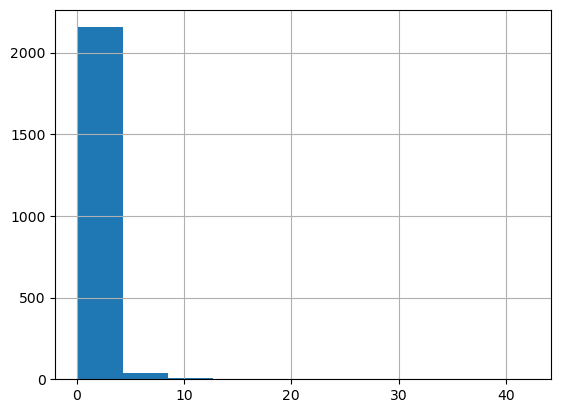

In [10]:
df_new_wis.wis_norm.hist()

### Ranking models

for 'PR'

In [12]:
m_wis_norm = (
    df_new_wis
    .groupby(["adm_1", "model"], as_index=False)["wis_norm"]
    .mean()
)

m_wis_norm["rank"] = (
    m_wis_norm
    .groupby("adm_1")["wis_norm"]
    .rank(method="first", ascending=True)
    .astype(int)
)

rank_wis_norm = (
    m_wis_norm
    .sort_values(["adm_1", "rank"])
)

rank_wis_norm.head()

,adm_1,model,wis_norm,rank
4,11,3rd_imdc_emap_epidematicos_sarimax_state,0.407169,1
17,11,3rd_imdc_pucrio_arbocaster,0.418089,2
11,11,3rd_imdc_ifgw_inframind-proteus,0.424080,3
13,11,3rd_imdc_lncc_lncc_arp26_dengue,0.424529,4
3,11,3rd_imdc_emap_epidematicos_prophet,0.465263,5


In [13]:
rank_wis_norm.to_csv('predictions/default_norm_rk.csv.gz', index = False)

#### WIS all: 

In [14]:
def compute_metrics(model, df_w, df_preds_, adm_1=None):
    '''
    Function to compute the score for the entire validation test or only around the peak (if peak=True).
    '''

    df_preds_2 = df_preds_
    df_w2 = df_w
        
    df_preds_model = df_preds_2.loc[df_preds_2.model == model].reset_index(drop = True)
        
    df_preds_to_score = df_w2.merge(df_preds_model, left_on = ['date', 'adm_1'], right_on = ['date', 'adm_1'])

    wis = np.mean(compute_wis( 
                        df_preds_to_score[['date',  'lower_95', 'lower_90', 'lower_80', 'lower_50',
                           'pred', 'upper_50', 'upper_80', 'upper_90', 'upper_95']],
                        observed_value = df_preds_to_score['casos'].values)) 
    return wis

In [18]:
df_metrics = pd.DataFrame()

for model in df_preds.model.unique(): 

    for state in df_preds.adm_1.unique():

        if state != 32:  

            wis = compute_metrics(model, df_dengue_state.loc[df_dengue_state.adm_1 == state],
                        df_preds.loc[df_preds.adm_1 == state])
            
            df_metrics = pd.concat([df_metrics,
                                pd.DataFrame([[model, state, 'all', wis ]],
                                    columns = ['model', 'adm_1', 'validation_test', 'WIS'] 
                                    )], ignore_index = True)
            

df_metrics['rank'] = df_metrics.groupby('adm_1')['WIS'].rank(method='first').astype(int)

rank_wis = df_metrics.sort_values('rank')        

rank_wis

,model,adm_1,validation_test,WIS,rank
26,3rd_imdc_purdue_neuralearth,12,all,42.991473,1
521,3rd_imdc_emap_epidematicos_sarimax_state,27,all,51.189035,1
525,3rd_imdc_emap_epidematicos_sarimax_state,23,all,84.664824,1
477,3rd_imdc_emap_epidematicos_prophet,41,all,2024.136985,1
141,3rd_imdc_lncc_lncc_arp26_dengue,50,all,133.889378,1
...,...,...,...,...,...
504,3rd_imdc_fgv_sakhal,26,all,1118.811282,21
502,3rd_imdc_fgv_sakhal,15,all,1866.998200,21
499,3rd_imdc_fgv_sakhal,23,all,631.058879,21
508,3rd_imdc_fgv_sakhal,21,all,332.220768,21


In [20]:
rank_wis.loc[rank_wis.adm_1 == 12]

,model,adm_1,validation_test,WIS,rank
26,3rd_imdc_purdue_neuralearth,12,all,42.991473,1
156,3rd_imdc_procc_bb_model,12,all,45.008233,2
312,3rd_imdc_pucrio_arbocaster,12,all,46.140064,3
390,3rd_imdc_universidad_del_valle_grupo_modelamie...,12,all,46.272612,4
364,3rd_imdc_emap_xgbsillas,12,all,47.620159,5
78,3rd_imdc_bsc_ghr,12,all,48.823415,6
468,3rd_imdc_emap_epidematicos_prophet,12,all,50.209774,7
442,3rd_imdc_cornell_bentolab,12,all,52.371819,8
520,3rd_imdc_emap_epidematicos_sarimax_state,12,all,52.670298,9
130,3rd_imdc_lncc_lncc_arp26_dengue,12,all,54.791048,10


In [21]:
rank_wis.to_csv('predictions/default_rk.csv.gz', index = False)

In [17]:
df_metrics

,model,adm_1,validation_test,WIS
0,3rd_imdc_isi_isi-dengue,12,all,123.220085
1,3rd_imdc_isi_isi-dengue,27,all,276.039214
2,3rd_imdc_isi_isi-dengue,16,all,63.380401
3,3rd_imdc_isi_isi-dengue,13,all,120.163136
4,3rd_imdc_isi_isi-dengue,29,all,1100.342920
...,...,...,...,...
562,3rd_imdc_emap_epidematicos_sarimax_state,31,all,8360.595899
563,3rd_imdc_emap_epidematicos_sarimax_state,43,all,1386.571959
564,3rd_imdc_emap_epidematicos_sarimax_state,11,all,37.760573
565,3rd_imdc_emap_epidematicos_sarimax_state,52,all,1153.330725


Plot individual: 

In [ ]:
from epiweeks import Week 

In [ ]:
def plot_comp_models(df_dengue_state, df_preds, b_model_all, b_model_norm, state): 
    
    df_dengue_41 = df_dengue_state.loc[(df_dengue_state.adm_1 == state) & (df_dengue_state.date >= pd.to_datetime(Week(2022,41).startdate()))]

    df_preds_norm = df_preds.loc[(df_preds.model == b_model_norm) & (df_preds.adm_1 == state)].sort_values(by = 'date')
    df_preds_all = df_preds.loc[(df_preds.model == b_model_all) & (df_preds.adm_1 == state)].sort_values(by = 'date')

    _,ax = plt.subplots(figsize = (12, 4))

    ax.plot(df_dengue_41.date, df_dengue_41.casos, color = 'black', marker = '.')

    ax.plot(df_preds_norm.date, df_preds_norm.pred, color = 'tab:orange', label = 'Best model - norm')
    ax.fill_between(df_preds_norm.date, df_preds_norm.lower_90, df_preds_norm.upper_90, color = 'tab:orange', alpha= 0.1)

    ax.plot(df_preds_all.date, df_preds_all.pred, color = 'tab:blue', label = 'Best model - all')
    ax.fill_between(df_preds_all.date, df_preds_all.lower_90, df_preds_all.upper_90, color = 'tab:blue', alpha= 0.1)
    ax.legend()
    ax.set_title(f'{challenge} - {state}')
    plt.show()


### Primeiro relatório: 


Média do WIS entre 202241 - 202540 (3 períodos de validação)

### Segundo relatório - uma média ponderada pelo total de casos na temporada: 

Para cada período é calculado: 
$$
\text{WIS}^{\text{norm}} = \frac{\sum_{t=1}^{T} \text{WIS}_t}{Y_\text{total}},
$$

where:
- $\text{WIS}_t$: Weighted Interval Score for week *t*  
- $Y_\text{total}$: Total number of cases in the period  
- $T$: Total number of weeks in the validation period  


Os modelos são rankeados a partir da **média** do $\text{WIS}^{\text{norm}}$ nos três perídos


A ideia dessa segunda abordagem foi tentar evitar modelos que capturaram muito bem 2024, mas previram temporadas muito altas, que não concretizaram, para as outras temporadas, ou tenha previsto bem 2024, mas muito pior as outras temporadas. **Mas acho que podemos pensar em algo mais elegante**

$$R_v = \cfrac{WIS_{model,v}}{WIS_{baseline,v}}

In [ ]:
#35
state = 35
b_model_norm = '3rd_imdc_lncc_lncc_arp26_dengue'
b_model_all = '3rd_imdc_pucrio_arbocaster'

plot_comp_models(df_dengue_state, df_preds, b_model_all, b_model_norm, state)

In [ ]:
#41
state = 41
b_model_norm = '3rd_imdc_lncc_lncc_arp26_dengue'
b_model_all = '3rd_imdc_emap_epidematicos_prophet'

plot_comp_models(df_dengue_state, df_preds, b_model_all, b_model_norm, state)

In [ ]:
state = 33
b_model_norm = '3rd_imdc_emap_lstm'
b_model_all = '3rd_imdc_pucrio_arbocaster'

plot_comp_models(df_dengue_state, df_preds, b_model_all, b_model_norm, state)